PROYECTO FINAL PDS II  
Estimación de madurez de mango
para exportación    

INTEGRANTES:    
Yovera Sirlupu Dany Smith    
Viera Calle Kevin Jaime    
Lopez Silupu Joseph Enrique    
Yovera Huancas Francisco Alexander    
Ramos Huertas Miguel Angel    
Cordova Abad Bruno Paolo    
Goicochea Calderon Sergio Eduardo    

#### **Sync Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### **Dependencies**

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

#### **Function to extract information from an image**

In [4]:
def InfoImg(img):
    print('size:',img.shape)
    print('max val:',np.max(img))
    print('min val:',np.min(img))
    print('mean val:',round(np.mean(img)))

Cargamos la Imagen a analizar

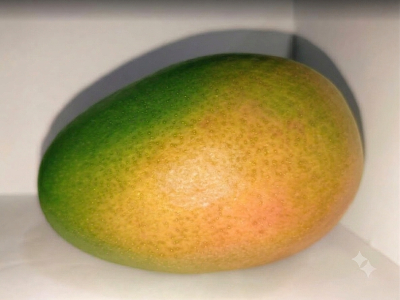

size: (300, 400, 3)
max val: 255
min val: 0
mean val: 144


In [46]:
img = cv2.imread('/content/drive/MyDrive/PROYECTO.MANGO/DATASET.MANGOS/PRUEBA M40%.png')
img_res = cv2.resize(img, (400, 300))
cv2_imshow(img_res)
InfoImg(img_res)

Realizamos la conversion a entorno HSV  
visualizacion independiente de sus canales  

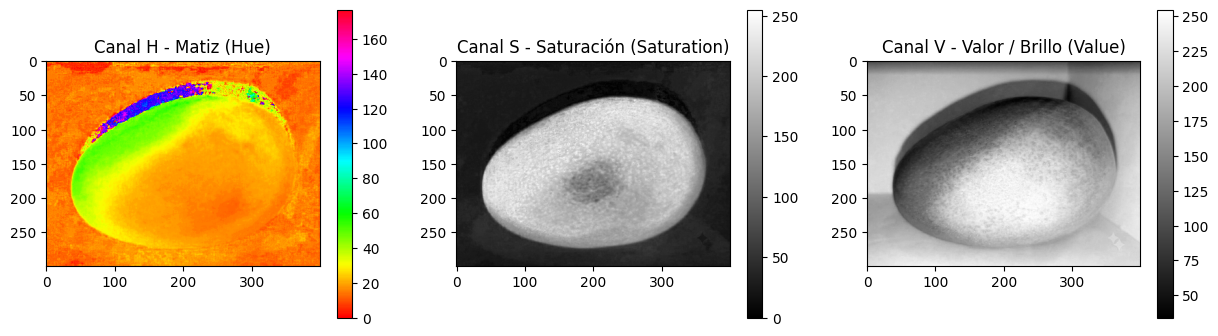

In [47]:
img_rgb = cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_res, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img_hsv)

plt.figure(figsize=(15, 4))

# Gráfico para el canal H (Matiz)
plt.subplot(131)
plt.imshow(h, 'hsv')
plt.title('Canal H - Matiz (Hue)')
plt.colorbar()

# Gráfico para el canal S (Saturación)
plt.subplot(132)
plt.imshow(s, 'gray')
plt.title('Canal S - Saturación (Saturation)')
plt.colorbar()

# Gráfico para el canal V (Valor / Brillo) 
plt.subplot(133)
plt.imshow(v, 'gray')
plt.title('Canal V - Valor / Brillo (Value)')
plt.colorbar()

plt.show()

Segmentacion de Regiones (Aislamos unicamente el mango)

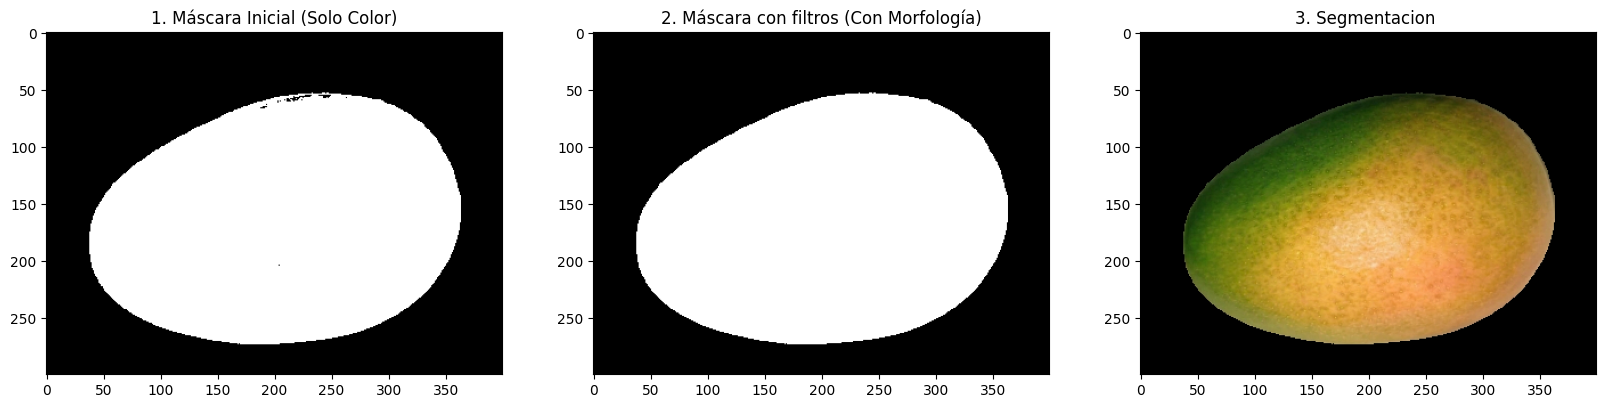

In [48]:
# Definimos los umbrales HSV basándonos en las gráficas
bajo_mango = np.array([0, 88, 40])
alto_mango = np.array([180, 255, 255])

# Creamos la máscara inicial por color
mascara = cv2.inRange(img_hsv, bajo_mango, alto_mango)

# Aplicar Filtros Morfológicos para perfeccionar
# Creamos un elemento estructurante (un núcleo elíptico)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

# Aplicamos la operacion Closing
# Cerrar huecos internos dentro del mango
mascara_cerrada = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)

# Aplicamos la operacion opening
# Eliminar ruido externo en el fondo
mascara_limpia = cv2.morphologyEx(mascara_cerrada, cv2.MORPH_OPEN, kernel)

# Aplicamos la operacion and en la imagen y la mascara
mango_segmentado = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara_limpia)

# Visualizamos resultados
plt.figure(figsize=(20, 10))

plt.subplot(131)
plt.imshow(mascara, cmap='gray')
plt.title('1. Máscara Inicial (Solo Color)')

plt.subplot(132)
plt.imshow(mascara_limpia, cmap='gray')
plt.title('2. Máscara con filtros (Con Morfología)')

plt.subplot(133)
plt.imshow(mango_segmentado)
plt.title('3. Segmentacion ')

plt.show()

Analisis del Histograma 

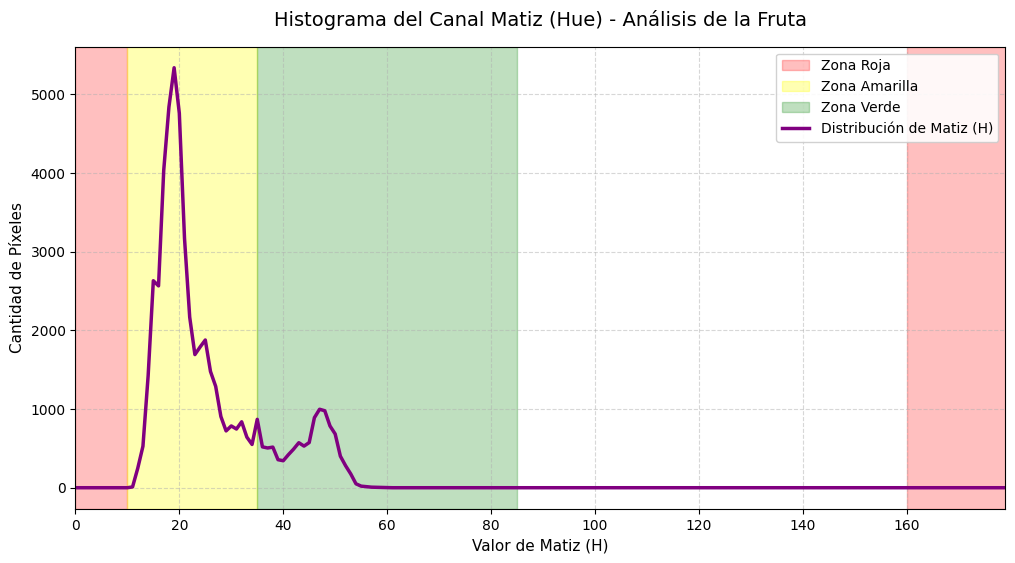

In [49]:
hsv_mango = cv2.cvtColor(mango_segmentado, cv2.COLOR_RGB2HSV)
h_mango, _, _ = cv2.split(hsv_mango)
hist_h = cv2.calcHist([h_mango], [0], mascara_limpia, [180], [0, 180])

# Configuraciones de la figura
plt.figure(figsize=(12, 6))
plt.title('Histograma del Canal Matiz (Hue) - Análisis de la Fruta', fontsize=14, pad=15)
plt.xlabel('Valor de Matiz (H)', fontsize=11)
plt.ylabel('Cantidad de Píxeles', fontsize=11)

# Distribucion de colores en el canal H
plt.axvspan(0, 10, color='red', alpha=0.25, label='Zona Roja')
plt.axvspan(10, 35, color='yellow', alpha=0.3, label='Zona Amarilla')
plt.axvspan(35, 85, color='green', alpha=0.25, label='Zona Verde')
plt.axvspan(160, 180, color='red', alpha=0.25) # El rojo en OpenCV vuelve a empezar al final (160-180)

# Curva del histograma 
plt.plot(hist_h, color='purple', linewidth=2.5, label='Distribución de Matiz (H)')
plt.xlim([0, 179])
plt.grid(True, linestyle='--', alpha=0.5)

# Leyenda
plt.legend(loc='upper right', framealpha=0.9)

plt.show()

Cuantificacion de Pixeles 

In [ ]:
# Conteo de píxeles por zonas usando tus mismos índices del histograma
cant_rojo = np.sum(hist_h[0:11]) + np.sum(hist_h[160:181])
cant_amarillo = np.sum(hist_h[11:35])
cant_verde = np.sum(hist_h[35:85])

# Total de píxeles reales de la fruta
total_pixeles_mango = cant_rojo + cant_amarillo + cant_verde

# SISTEMA DE CUANTIFICACIÓN PONDERADA
# Asignamos pesos: Verde = 0.0 | Amarillo = 0.75 | Rojo = 0.85
peso_verde = 0.0
peso_amarillo = 0.75
peso_rojo = 0.85

# Fórmula del Índice de Madurez General Ponderado
indice_madurez_ponderado = (
    (cant_verde * peso_verde) + 
    (cant_amarillo * peso_amarillo) + 
    (cant_rojo * peso_rojo)
) / total_pixeles_mango * 100

# CLASIFICACIÓN EN CATEGORÍAS AUTOMÁTICAS POR PORCENTAJE
# Evaluamos el índice ponderado para determinar el estado exacto de la fruta

if indice_madurez_ponderado < 60.0:
    categoria_fruta = "VERDE (Inmaduro)"
    
elif 60.0 <= indice_madurez_ponderado <= 70.0:
    categoria_fruta = "SEMIMADURO"
    
else:  # Cuando sobrepasa el 75.0%
    categoria_fruta = "MADURO"

# IMPRESIÓN DE RESULTADOS MÁS PRECISOS
print("====================================================")
print("      RESULTADOS DE CUANTIFICACIÓN        ")
print("====================================================")
print(f"Píxeles Verdes:             {int(cant_verde)}")
print(f"Píxeles Amarillos:          {int(cant_amarillo)}")
print(f"Píxeles Rojos:              {int(cant_rojo)}")
print(f"Total Píxeles Fruta:        {int(total_pixeles_mango)}")
print("----------------------------------------------------")
print(f"▶ Categoría del Mango:       {categoria_fruta}")
print(f"▶ Índice de Madurez Real:   {indice_madurez_ponderado:.2f}%")
print("====================================================")

      RESULTADOS DE CUANTIFICACIÓN        
Píxeles Verdes:             10981
Píxeles Amarillos:          45014
Píxeles Rojos:              0
Total Píxeles Fruta:        55995
----------------------------------------------------
▶ Categoría del Mango:       SEMIMADURO
▶ Índice de Madurez Real:   60.29%


Prediccion de vida util 

In [ ]:
# Mapeo de días ajustado al índice ponderado
# Un mango 100% verde (0% madurez) -> ~20 días de viaje
# Un mango 100% amarillo (~75% madurez) -> ~6 días de viaje

madurez_min = 0.0   
dias_max = 20.0     

madurez_max = 75.0  
dias_min = 6.0      

# Ecuación de interpolación
dias_restantes = dias_max + ((dias_min - dias_max) / (madurez_max - madurez_min)) * (indice_madurez_ponderado - madurez_min)
dias_estimados = np.clip(dias_restantes, a_min=1.0, a_max=dias_max)

print(f"▶ Estimación de Vida Útil:   {dias_estimados:.1f} días restantes .")

▶ Estimación de Vida Útil:   8.7 días restantes .
